In [4]:
import cfg
from libs.data_request import DataRequest
from libs.analysis import PSDHistogram

import redis
import pickle

log = cfg.set_logger()
dr = DataRequest(log=log, base_url=cfg.API_URL)
r = redis.Redis()

camp_ids = {'3KRBW': 193}
target_nodes = [1,3,4,5,9]

[IPYKERNEL_LAUNCHER]INFO      Initialized DataRequest class with base_url: https://rsm.ane.gov.co:12443/api


In [5]:
if r.exists('df_rbw'):
    df_rbw = pickle.loads(r.get('df_rbw'))
else:
    df_rbw = dr.load_campaigns_and_nodes(campaigns=camp_ids, node_ids=target_nodes)
    r.set('df_rbw', pickle.dumps(df_rbw))

datos_nodos = df_rbw["3KRBW"]

[IPYKERNEL_LAUNCHER]INFO      Loading data for campaigns: ['3KRBW'] and nodes: [1, 3, 4, 5, 9]

🚀 Starting Campaign: 3KRBW


  ↳ Node 1: 1page [00:01,  1.78s/page]
  ↳ Node 3: 1page [00:02,  2.55s/page]
  ↳ Node 4: 1page [00:02,  2.25s/page]
  ↳ Node 5: 1page [00:02,  2.85s/page]
  ↳ Node 9: 1page [00:01,  1.73s/page]

[IPYKERNEL_LAUNCHER]INFO      Finished loading data for all campaigns and nodes.


Parsing pxx across 5 nodes for Histograms...


100%|██████████| 5/5 [00:00<00:00, 11.98it/s]


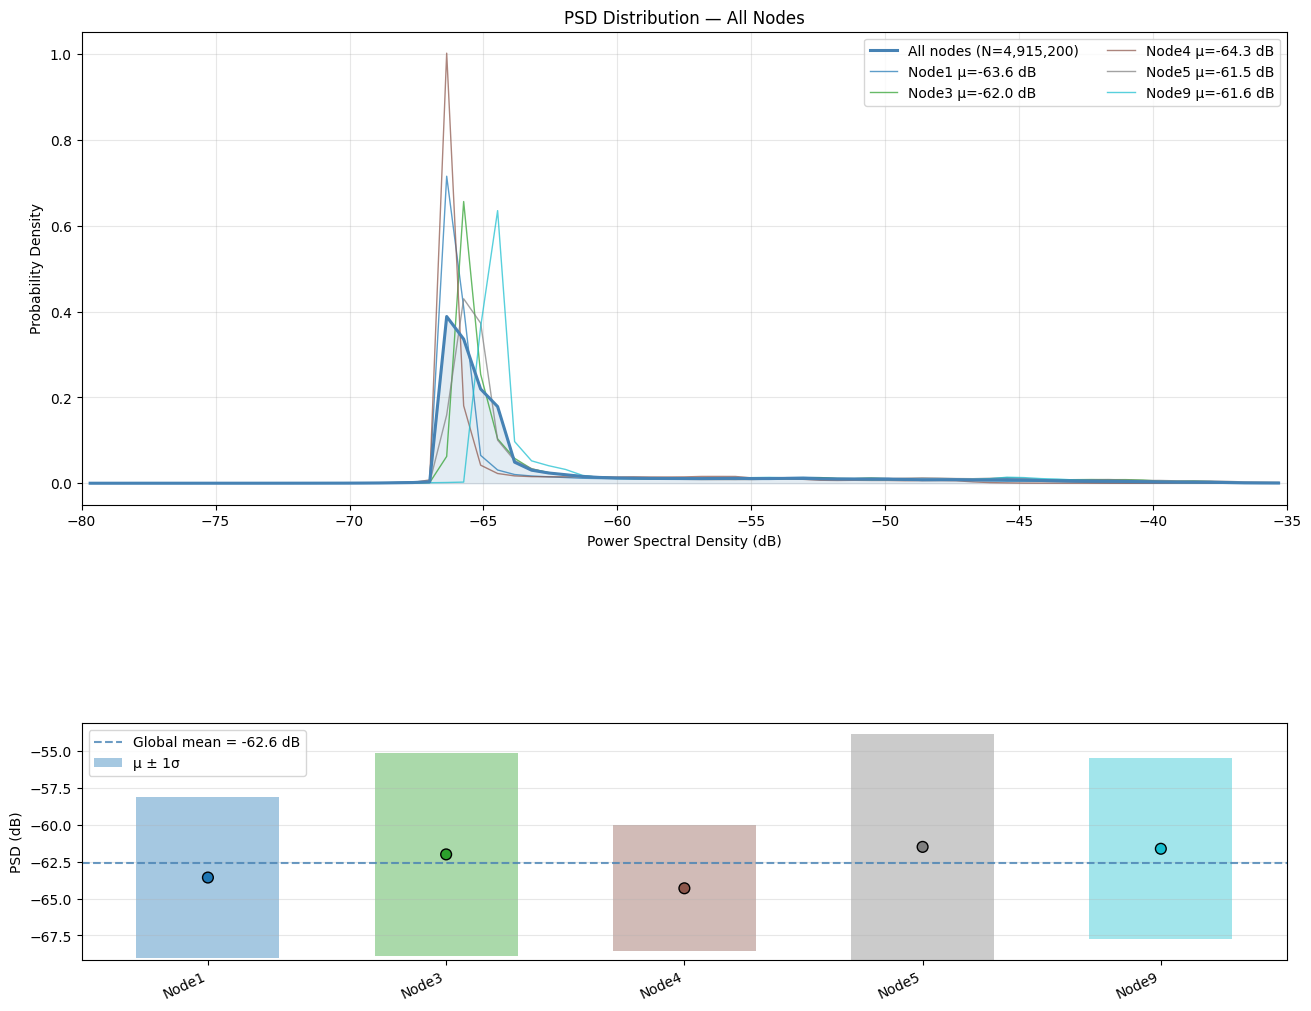


Computing Mutual Information Matrix (Single Row Alignment)...


100%|██████████| 5/5 [00:00<00:00, 467.96it/s]


 Nodes ranked by Product Score:
Rank   Label                Corr         MI           Product     
----------------------------------------------------------------------
1      Node5                     0.5891      0.9073      0.7482
2      Node3                     0.4932      1.0000      0.7466
3      Node1                     0.5314      0.9487      0.7400
4      Node4                     0.3918      0.9350      0.6634
5      Node9                     0.1841      0.8867      0.5354


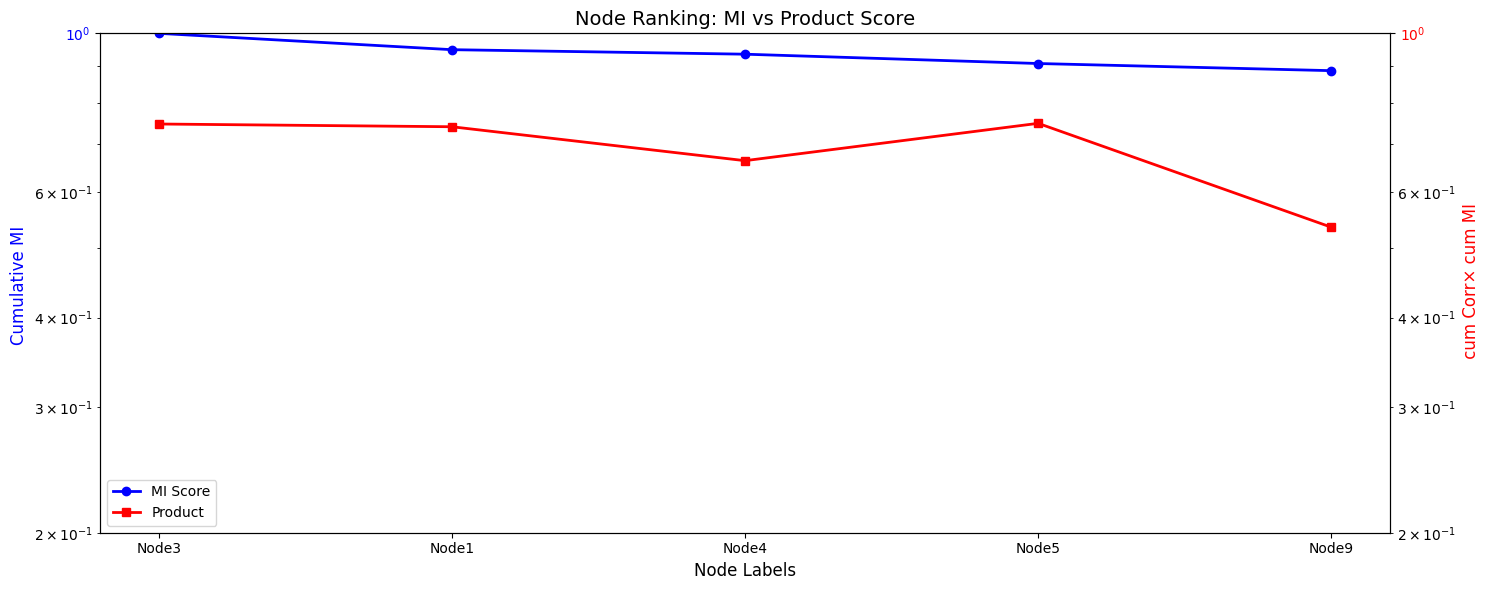

In [10]:
#Initialize the analyzer
analyzer = PSDHistogram(datos_nodos, global_range=(-80, -35))

#Execute Histogram Analysis
# This parses all rows, calculates densities, and plots Panel A (Overlay) and Panel B (Mean/Std)
analyzer.execute_histogram()

# Execute Cumulative Ranking
# This aligns single-row vectors for MI, calculates the correlation matrix from densities,
# computes the weighted product (alpha=0.5), prints the rank table, and shows the log-scale plot.
analyzer.exec_cumm_ranking(normalized=False, alpha=0.5)